# Food Detection + Calorie & Health-Suitability Assistant
### (Elderly health-check app — Pakistan)

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

BASE_DIR = '/content/drive/MyDrive/FoodHealthApp'
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
WEIGHTS_DIR = os.path.join(BASE_DIR, 'weights')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
EXPORT_DIR = os.path.join(BASE_DIR, 'exports')
NUTRITION_DIR = os.path.join(BASE_DIR, 'nutrition')
CHARTS_DIR = os.path.join(BASE_DIR, 'charts')

for d in [BASE_DIR, DATASET_DIR, WEIGHTS_DIR, RESULTS_DIR, EXPORT_DIR, NUTRITION_DIR, CHARTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Project folders ready under:', BASE_DIR)


Project folders ready under: /content/drive/MyDrive/FoodHealthApp


In [6]:
!pip install -q ultralytics roboflow pandas matplotlib seaborn requests


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.1 MB/s eta 0:00:00


In [61]:
from getpass import getpass
from roboflow import Roboflow
import yaml

api_key = getpass('enter api key: ')
rf = Roboflow(api_key=api_key)

{
        'name': 'fast_food_classification',
        'workspace': 'abdul-ikram-nz2nx',
        'project': 'fast-food-classification-ddqyc',
        'version': 1,
        'export_format': 'multiclass'
    }

DATASETS_TO_DOWNLOAD = [
    {
        'name': 'my_original_food_dataset',
        'workspace': 'project-4lmm2',
        'project': 'foods-qshht',
        'version': 7
    },
    {
        'name': 'indian_food_detection',
        'workspace': 'project-z0tql',
        'project': 'indian-food-detection-kzw9g',
        'version': 1
    },
    {
        'name': 'multi_object_food',
        'workspace': 'workeveryday',
        'project': 'multi-object-food-detection',
        'version': 1
    },
    {
        'name': 'fruits_and_vegetables',
        'workspace': 'datasets-wqqwv',
        'project': 'fruits-and-vegetables-un1ow',
        'version': 2
    },
    {
        'name': 'fast_food_alt',
        'workspace': 'ntsuu',
        'project': 'fast-food-ufdjx',
        'version': 19
    }
]

downloaded_datasets = {}
all_classes = {}

for entry in DATASETS_TO_DOWNLOAD:
    print(f"\nDownloading '{entry['name']}' ({entry['workspace']}/{entry['project']} v{entry['version']}) ...")
    try:
        project = rf.workspace(entry['workspace']).project(entry['project'])
        version = project.version(entry['version'])
        dest = os.path.join(DATASET_DIR, entry['name'])
        dataset = version.download('yolov8', location=dest)
        downloaded_datasets[entry['name']] = dataset

        with open(os.path.join(dataset.location, 'data.yaml')) as f:
            classes = yaml.safe_load(f).get('names', [])
        all_classes[entry['name']] = classes
        print(f"  -> {len(classes)} classes: {classes}")
    except Exception as e:
        print(f"  !! Skipped '{entry['name']}': {e}")
        print('     Double check the workspace/project/version match the dataset\'s Roboflow page exactly.')


enter api key: ··········

loading Roboflow workspace...
loading Roboflow project...
  -> 17 classes: ['Apple', 'Banana', 'Cabbage', 'Carrot', 'ChineseCabbage', 'Cucumber', 'GreenOnion', 'GreenPepper', 'Lettuce', 'MiniTomato', 'Onion', 'PineApple', 'Potato', 'Radhish', 'Spinach', 'StrawBerry', 'Tomato']

loading Roboflow workspace...
loading Roboflow project...
  -> 17 classes: ['Bhatura', 'BhindiMasala', 'Biryani', 'Chole', 'ShahiPaneer', 'chicken', 'dal', 'dhokla', 'gulab_jamun', 'idli', 'jalebi', 'modak', 'palak_paneer', 'poha', 'rice', 'roti', 'samosa']

loading Roboflow workspace...
loading Roboflow project...
  -> 10 classes: ['burger', 'donut', 'frenchfries', 'ikan goreng', 'kangkung', 'kopi hitam', 'nasi', 'pizza', 'sate', 'telur balado']

loading Roboflow workspace...
loading Roboflow project...
  -> 4 classes: ['Apple-Fresh', 'Apple-Rotten', 'Banana-Fresh', 'Banana-Rotten']

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/drive/MyDrive/FoodHealthApp/dataset/fast_food_alt in yolov8:: 100%|██████████| 3571/3571 [00:52<00:00, 68.40it/s] 


  -> 12 classes: ['A00101013', 'A00101019', 'A00101020', 'A00102005', 'A00201001', 'A00201009', 'A00201012', 'A00201014', 'A00201015', 'A00201016', 'A00202001', 'A00202005']


In [63]:


master_classes = sorted({cls for classes in all_classes.values() for cls in classes})

print(f'{len(master_classes)} unique classes across {len(all_classes)} dataset(s):\n')
for c in master_classes:
    print(' -', c)

with open(os.path.join(DATASET_DIR, 'master_class_list.txt'), 'w') as f:
    f.write('\n'.join(master_classes))
print('\nSaved to', os.path.join(DATASET_DIR, 'master_class_list.txt'))


60 unique classes across 5 dataset(s):

 - A00101013
 - A00101019
 - A00101020
 - A00102005
 - A00201001
 - A00201009
 - A00201012
 - A00201014
 - A00201015
 - A00201016
 - A00202001
 - A00202005
 - Apple
 - Apple-Fresh
 - Apple-Rotten
 - Banana
 - Banana-Fresh
 - Banana-Rotten
 - Bhatura
 - BhindiMasala
 - Biryani
 - Cabbage
 - Carrot
 - ChineseCabbage
 - Chole
 - Cucumber
 - GreenOnion
 - GreenPepper
 - Lettuce
 - MiniTomato
 - Onion
 - PineApple
 - Potato
 - Radhish
 - ShahiPaneer
 - Spinach
 - StrawBerry
 - Tomato
 - burger
 - chicken
 - dal
 - dhokla
 - donut
 - frenchfries
 - gulab_jamun
 - idli
 - ikan goreng
 - jalebi
 - kangkung
 - kopi hitam
 - modak
 - nasi
 - palak_paneer
 - pizza
 - poha
 - rice
 - roti
 - samosa
 - sate
 - telur balado

Saved to /content/drive/MyDrive/FoodHealthApp/dataset/master_class_list.txt


In [71]:
import os, glob, shutil, yaml

# 1. bulk-copy the Drive datasets to local disk (one fast operation)
!mkdir -p /content/raw && cp -r "{DATASET_DIR}"/* /content/raw/ 2>/dev/null

# 2. merge locally
COMBINED = '/content/combined_food_dataset'
canon = lambda n: ' '.join(str(n).lower().replace('-',' ').replace('_',' ').split())

master_classes = sorted({canon(c) for cs in all_classes.values() for c in cs})
ids = {c: i for i, c in enumerate(master_classes)}

shutil.rmtree(COMBINED, ignore_errors=True)
for s in ['train','valid','test']:
    os.makedirs(f'{COMBINED}/{s}/images', exist_ok=True)
    os.makedirs(f'{COMBINED}/{s}/labels', exist_ok=True)

n = 0
for name in downloaded_datasets:
    loc = f'/content/raw/{name}'
    remap = {i: ids[canon(c)] for i, c in enumerate(all_classes[name])}
    for s in ['train','valid','test']:
        for img in glob.glob(f'{loc}/{s}/images/*'):
            stem = os.path.splitext(os.path.basename(img))[0]
            lbl = f'{loc}/{s}/labels/{stem}.txt'
            if not os.path.exists(lbl): continue
            out = [' '.join([str(remap[int(float(p[0]))])] + p[1:])
                   for p in (l.split() for l in open(lbl)) if len(p) >= 5]
            if not out: continue
            new = f'{name}__{stem}'
            shutil.copy(img, f'{COMBINED}/{s}/images/{new}{os.path.splitext(img)[1]}')
            open(f'{COMBINED}/{s}/labels/{new}.txt','w').write('\n'.join(out))
            n += 1

COMBINED_DATA_YAML = f'{COMBINED}/data.yaml'
yaml.safe_dump({'path': COMBINED, 'train':'train/images', 'val':'valid/images',
                'test':'test/images', 'nc': len(master_classes),
                'names': master_classes}, open(COMBINED_DATA_YAML,'w'), sort_keys=False)
print(f'{n} images, {len(master_classes)} classes -> {COMBINED_DATA_YAML}')

12186 images, 60 classes -> /content/combined_food_dataset/data.yaml


In [72]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.train(
    data=COMBINED_DATA_YAML,
    epochs=15,
    imgsz=416,
    project='/content/runs',
    name='food_detector',
    exist_ok=True,
)


Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/combined_food_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=food_detector, nbs=64, 

In [73]:
import os
import pandas as pd
from ultralytics import YOLO


best_weights = '/content/runs/food_detector/weights/best.pt'
model = YOLO(best_weights)


nutrition_csv_path = os.path.join(NUTRITION_DIR, 'nutrition_table.csv')
nutrition_df = pd.read_csv(nutrition_csv_path)


In [74]:
best_weights = '/content/runs/food_detector/weights/best.pt'
trained_model = YOLO(best_weights)

metrics = trained_model.val(data=COMBINED_DATA_YAML)
print(metrics)


Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,017,348 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1348.3±859.3 MB/s, size: 232.0 KB)
val: Scanning /content/combined_food_dataset/valid/labels.cache... 1614 images, 0 backgrounds, 7 corrupt: 100% ━━━━━━━━━━━━ 1614/1614 356.3Mit/s 0.0s
val: /content/combined_food_dataset/valid/images/indian_food_detection__chicken016_jpg.rf.3b3b500855796c139ea5daffe527991c.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/combined_food_dataset/valid/images/indian_food_detection__chicken039_jpg.rf.aa3dec0f5a0c58a4d8598e3323d4edf4.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/combined_food_dataset/valid/images/indian_food_detection__chicken077_jpg.rf.615973951934ff3af33e47b418c1a8d6.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content

KeyboardInterrupt: 

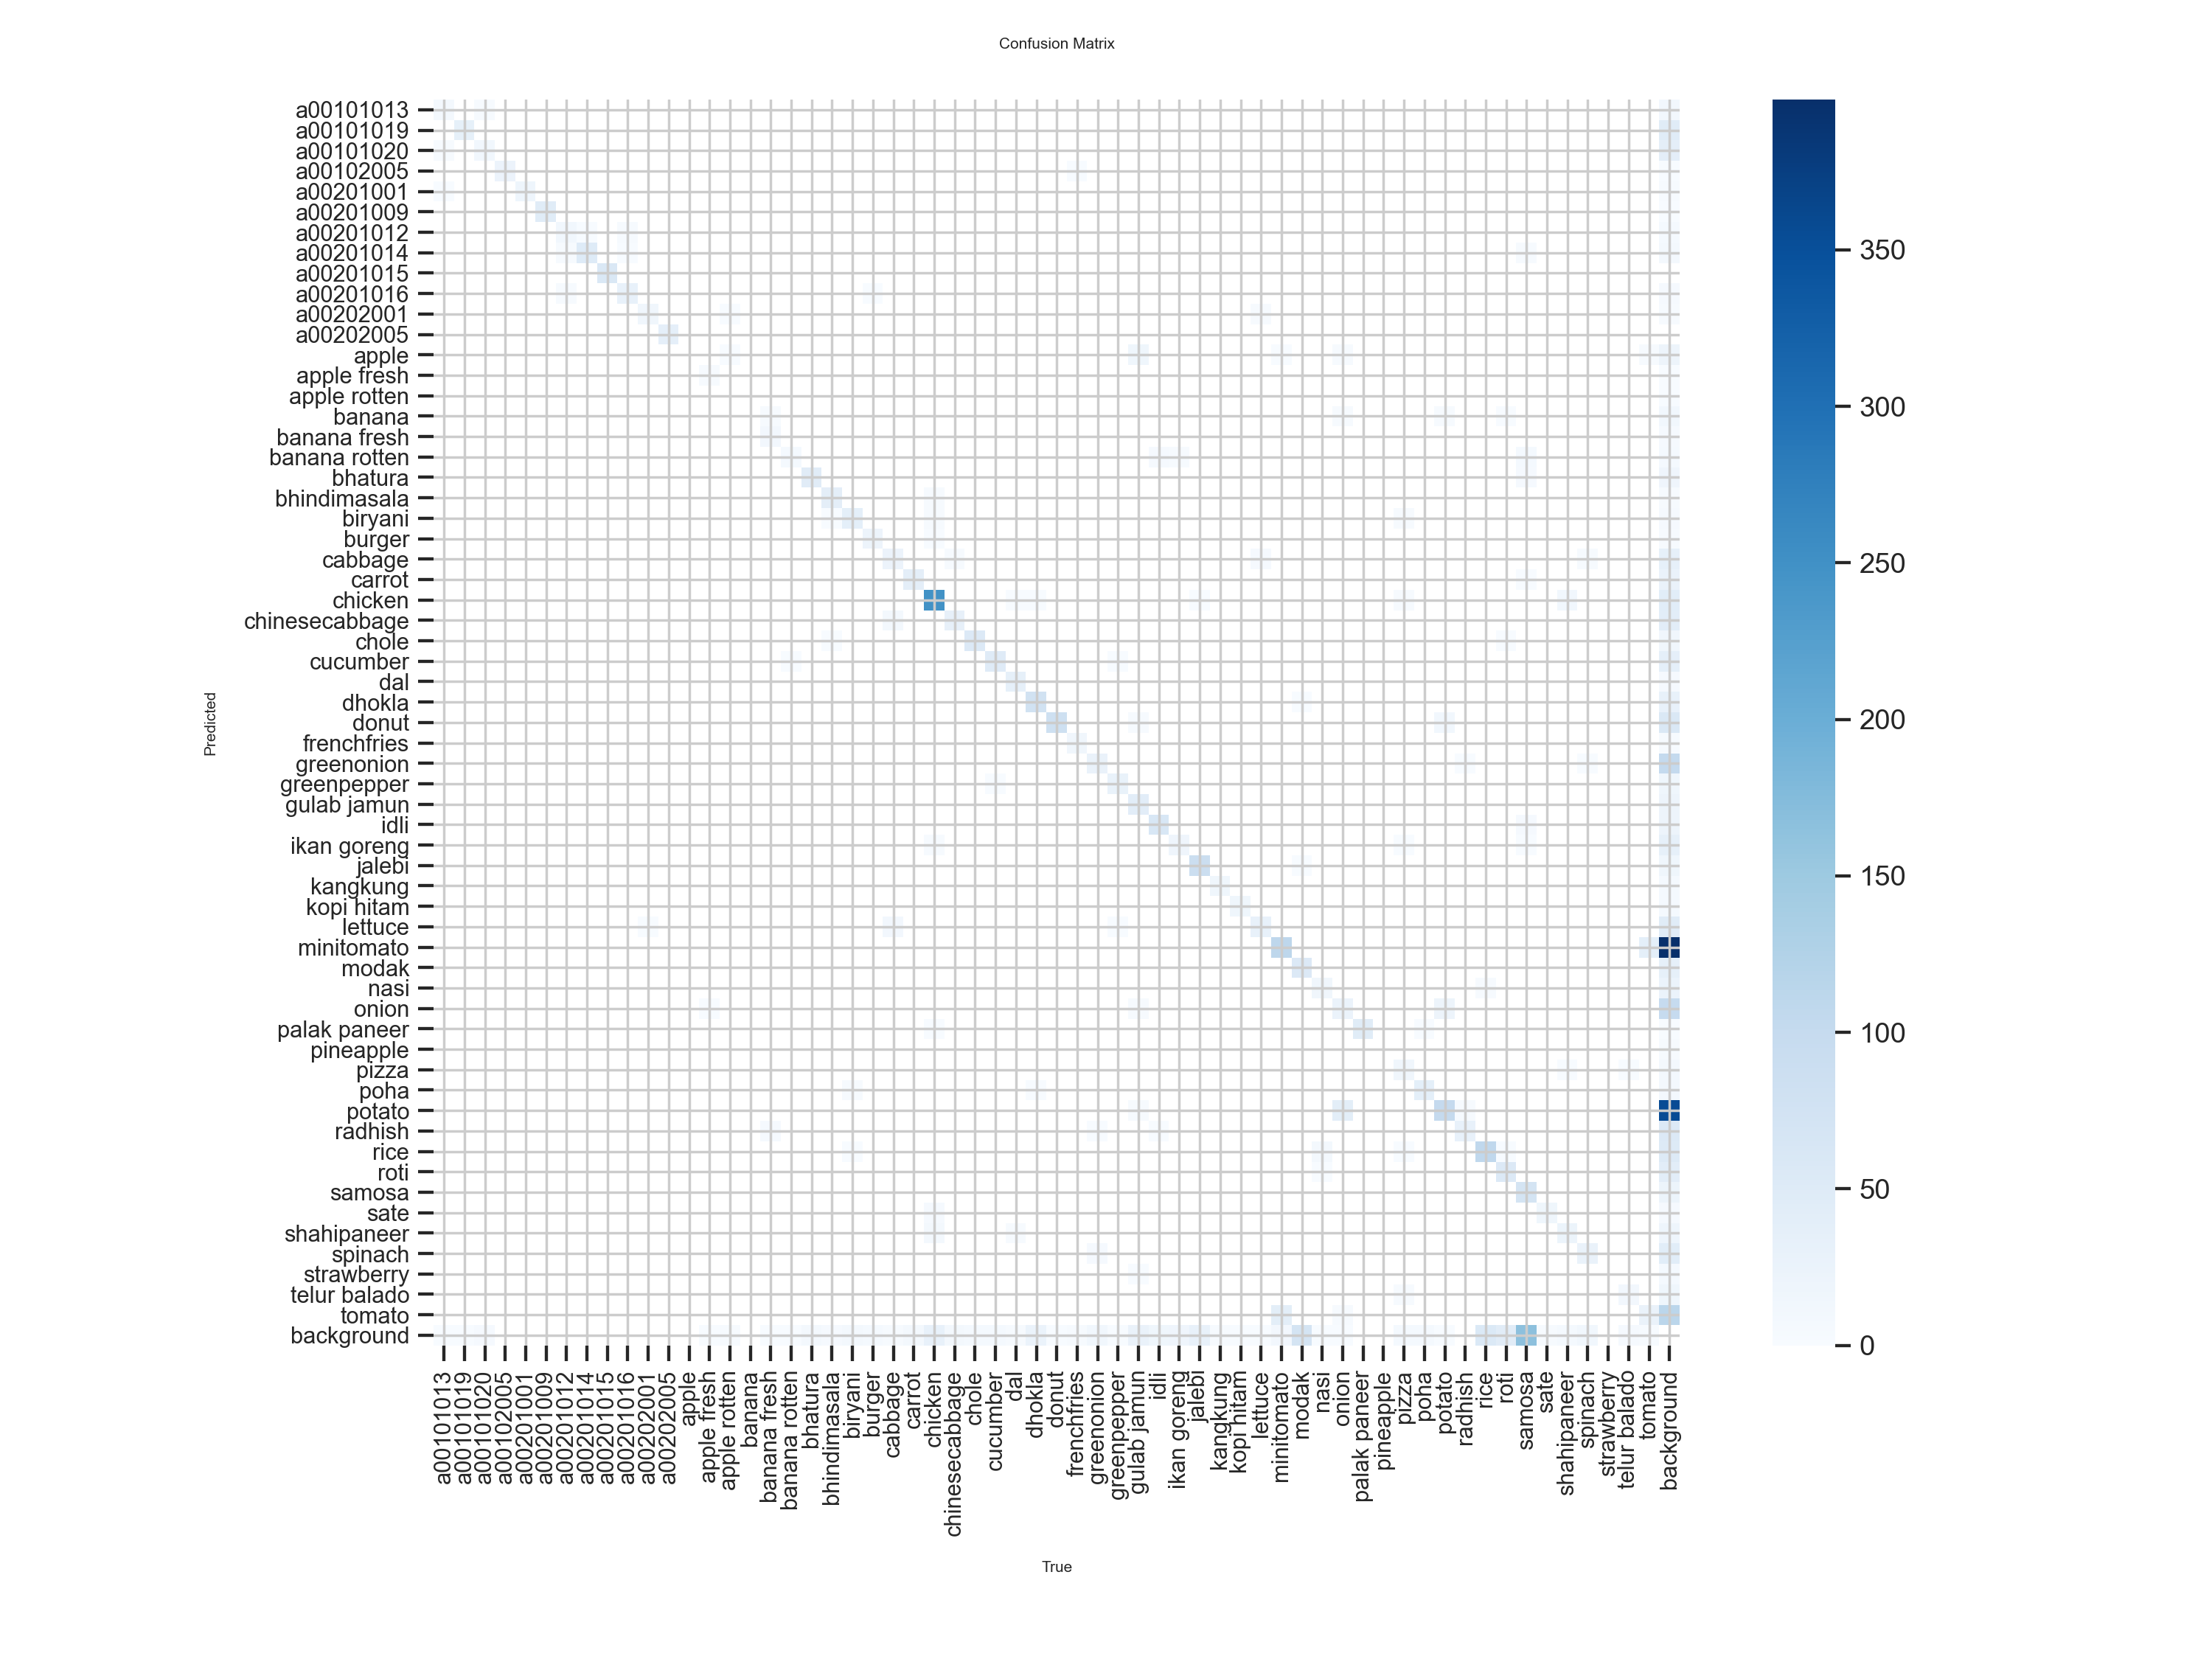

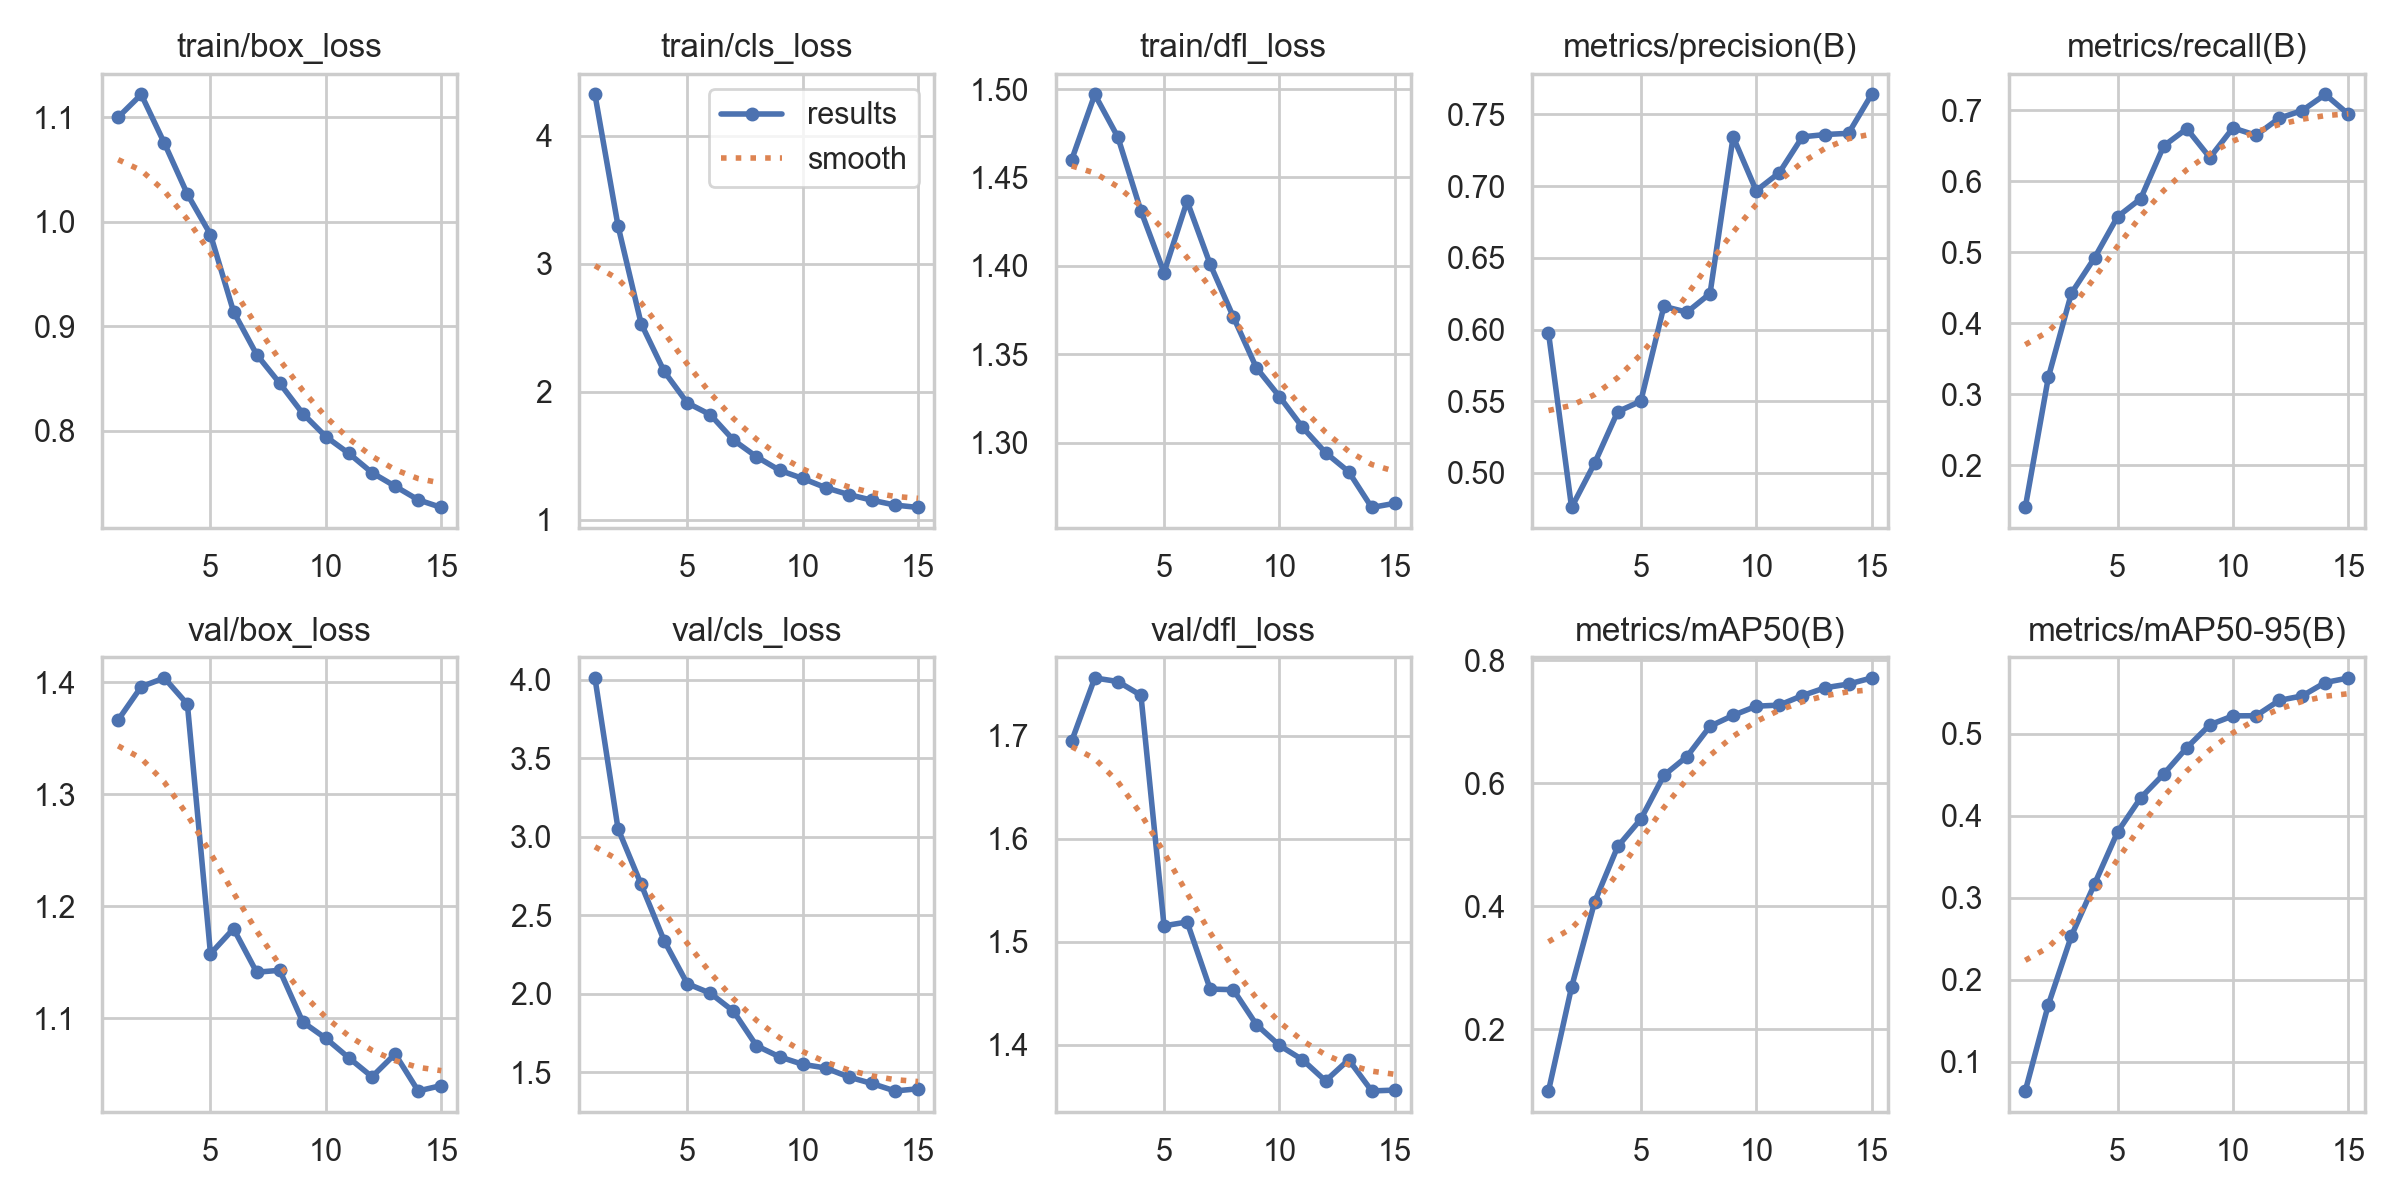

In [75]:
from IPython.display import Image, display

run_dir = '/content/runs/food_detector'
display(Image(filename=os.path.join(run_dir, 'confusion_matrix.png')))
display(Image(filename=os.path.join(run_dir, 'results.png'), width=700))


In [76]:
import requests
import time
import pandas as pd

usda_api_key = getpass('Enter your (free) USDA FoodData Central API key: ')

def query_usda_nutrition(food_name, api_key, timeout=10):
    """Looks up one food name in USDA FoodData Central and returns a dict of
    the nutrients we care about, or None if nothing usable was found."""
    url = 'https://api.nal.usda.gov/fdc/v1/foods/search'
    params = {'query': food_name, 'pageSize': 1, 'api_key': api_key}
    try:
        resp = requests.get(url, params=params, timeout=timeout)
        resp.raise_for_status()
        results = resp.json().get('foods', [])
    except Exception as e:
        print(f'  lookup failed for {food_name}: {e}')
        return None

    if not results:
        return None

    nutrients = {n['nutrientName']: n['value'] for n in results[0].get('foodNutrients', [])}

    def get(*names, default=0):
        for n in names:
            if n in nutrients:
                return nutrients[n]
        return default

    return {
        'class_name': food_name,
        'serving_description': '100g (USDA reference amount)',
        'calories': get('Energy'),
        'carbs_g': get('Carbohydrate, by difference'),
        'sugar_g': get('Sugars, total including NLEA', 'Sugars, total'),
        'fat_g': get('Total lipid (fat)'),
        'cholesterol_mg': get('Cholesterol'),
        'sodium_mg': get('Sodium, Na'),
        'source': 'USDA (auto)',
    }

rows = []
not_found = []

for food_name in master_classes:
    result = query_usda_nutrition(food_name, usda_api_key)
    if result:
        rows.append(result)
        print(f'  found: {food_name}')
    else:
        not_found.append(food_name)
        print(f'  NOT FOUND (needs manual entry): {food_name}')
    time.sleep(0.2)  # be polite to the free API

auto_nutrition_df = pd.DataFrame(rows) if rows else pd.DataFrame(columns=['class_name'])

print(f'\n{len(rows)} classes auto-filled, {len(not_found)} need manual entry.')
if not_found:
    print('Manual entry needed for:', not_found)


Enter your (free) USDA FoodData Central API key: ··········
  NOT FOUND (needs manual entry): a00101013
  NOT FOUND (needs manual entry): a00101019
  NOT FOUND (needs manual entry): a00101020
  NOT FOUND (needs manual entry): a00102005
  NOT FOUND (needs manual entry): a00201001
  NOT FOUND (needs manual entry): a00201009
  NOT FOUND (needs manual entry): a00201012
  NOT FOUND (needs manual entry): a00201014
  NOT FOUND (needs manual entry): a00201015
  NOT FOUND (needs manual entry): a00201016
  NOT FOUND (needs manual entry): a00202001
  NOT FOUND (needs manual entry): a00202005
  found: apple
  found: apple fresh
  found: apple rotten
  found: banana
  found: banana fresh
  found: banana rotten
  NOT FOUND (needs manual entry): bhatura
  NOT FOUND (needs manual entry): bhindimasala
  found: biryani
  found: burger
  found: cabbage
  found: carrot
  found: chicken
  NOT FOUND (needs manual entry): chinesecabbage
  found: chole
  found: cucumber
  found: dal
  found: dhokla
  found: d

In [77]:
manual_nutrition_rows = [
    # Fill these in / add more rows for whatever showed up in 'not_found' above.
    # VERIFY every value before using with real users.
    {'class_name': 'biryani', 'serving_description': '1 cup (~250g)', 'calories': 350, 'carbs_g': 45, 'sugar_g': 3,  'fat_g': 12, 'cholesterol_mg': 45,  'sodium_mg': 600, 'source': 'manual - VERIFY'},
    {'class_name': 'daal',    'serving_description': '1 cup (~200g)', 'calories': 200, 'carbs_g': 30, 'sugar_g': 2,  'fat_g': 5,  'cholesterol_mg': 0,   'sodium_mg': 400, 'source': 'manual - VERIFY'},
    {'class_name': 'roti',    'serving_description': '1 piece (~40g)', 'calories': 120, 'carbs_g': 22, 'sugar_g': 1,  'fat_g': 2,  'cholesterol_mg': 0,   'sodium_mg': 150, 'source': 'manual - VERIFY'},
    {'class_name': 'karahi',  'serving_description': '1 serving (~250g)', 'calories': 400, 'carbs_g': 10, 'sugar_g': 3, 'fat_g': 28, 'cholesterol_mg': 90,  'sodium_mg': 700, 'source': 'manual - VERIFY'},
    {'class_name': 'nihari',  'serving_description': '1 bowl (~300g)', 'calories': 450, 'carbs_g': 15, 'sugar_g': 2, 'fat_g': 30, 'cholesterol_mg': 100, 'sodium_mg': 800, 'source': 'manual - VERIFY'},
]

manual_nutrition_df = pd.DataFrame(manual_nutrition_rows)

nutrition_csv_path = os.path.join(NUTRITION_DIR, 'nutrition_table.csv')

# Manual entries take priority over auto-filled ones for the same class name.
combined = pd.concat([auto_nutrition_df, manual_nutrition_df], ignore_index=True)
nutrition_df = combined.drop_duplicates(subset='class_name', keep='last').reset_index(drop=True)

nutrition_df.to_csv(nutrition_csv_path, index=False)
print(f'Saved {len(nutrition_df)} rows to {nutrition_csv_path}')
nutrition_df


Saved 40 rows to /content/drive/MyDrive/FoodHealthApp/nutrition/nutrition_table.csv


,class_name,serving_description,calories,carbs_g,sugar_g,fat_g,cholesterol_mg,sodium_mg,source
0,apple,100g (USDA reference amount),52.0,14.30,0,0.65,0.0,0.0,USDA (auto)
1,apple fresh,100g (USDA reference amount),94.0,2.65,0,0.64,0.0,4.0,USDA (auto)
2,apple rotten,100g (USDA reference amount),134.0,29.61,0,2.15,2.0,62.0,USDA (auto)
3,banana,100g (USDA reference amount),312.0,40.60,0,6.25,0.0,594.0,USDA (auto)
4,banana fresh,100g (USDA reference amount),346.0,88.30,0,1.81,0.0,3.0,USDA (auto)
5,banana rotten,100g (USDA reference amount),346.0,88.30,0,1.81,0.0,3.0,USDA (auto)
6,burger,100g (USDA reference amount),88.0,23.50,0,0.00,0.0,3180.0,USDA (auto)
7,cabbage,100g (USDA reference amount),65.0,2.40,0,0.50,0.0,498.0,USDA (auto)
8,carrot,100g (USDA reference amount),44.0,9.68,0,0.24,0.0,75.0,USDA (auto)
9,chicken,100g (USDA reference amount),107.0,0.00,0,1.79,45.0,179.0,USDA (auto)


In [78]:
CONDITION_LIMITS = {
    'diabetes':          {'sugar_g': 10, 'carbs_g': 30},
    'high_cholesterol':  {'cholesterol_mg': 60, 'fat_g': 15},
    'hypertension':      {'sodium_mg': 400},
}

def check_food_suitability(food_name, user_conditions, nutrition_df=nutrition_df):
    row = nutrition_df[nutrition_df['class_name'].str.lower() == food_name.lower()]
    if row.empty:
        return f"{food_name}: no nutrition data yet."

    row = row.iloc[0]
    warnings = []
    for condition in user_conditions:
        for nutrient, limit in CONDITION_LIMITS.get(condition, {}).items():
            value = row.get(nutrient, 0)
            if pd.notna(value) and value > limit:
                warnings.append(f"{nutrient.replace('_', ' ')} is {value} (above the {limit} guideline for {condition})")

    if warnings:
        return f"{food_name.title()} ({row['calories']} kcal per {row['serving_description']}): CAUTION — " + '; '.join(warnings) + '.'
    return f"{food_name.title()} ({row['calories']} kcal per {row['serving_description']}): looks fine in a normal portion."

print(check_food_suitability('nihari', ['diabetes', 'high_cholesterol']))


Nihari (450.0 kcal per 1 bowl (~300g)): CAUTION — cholesterol mg is 100.0 (above the 60 guideline for high_cholesterol); fat g is 30.0 (above the 15 guideline for high_cholesterol).


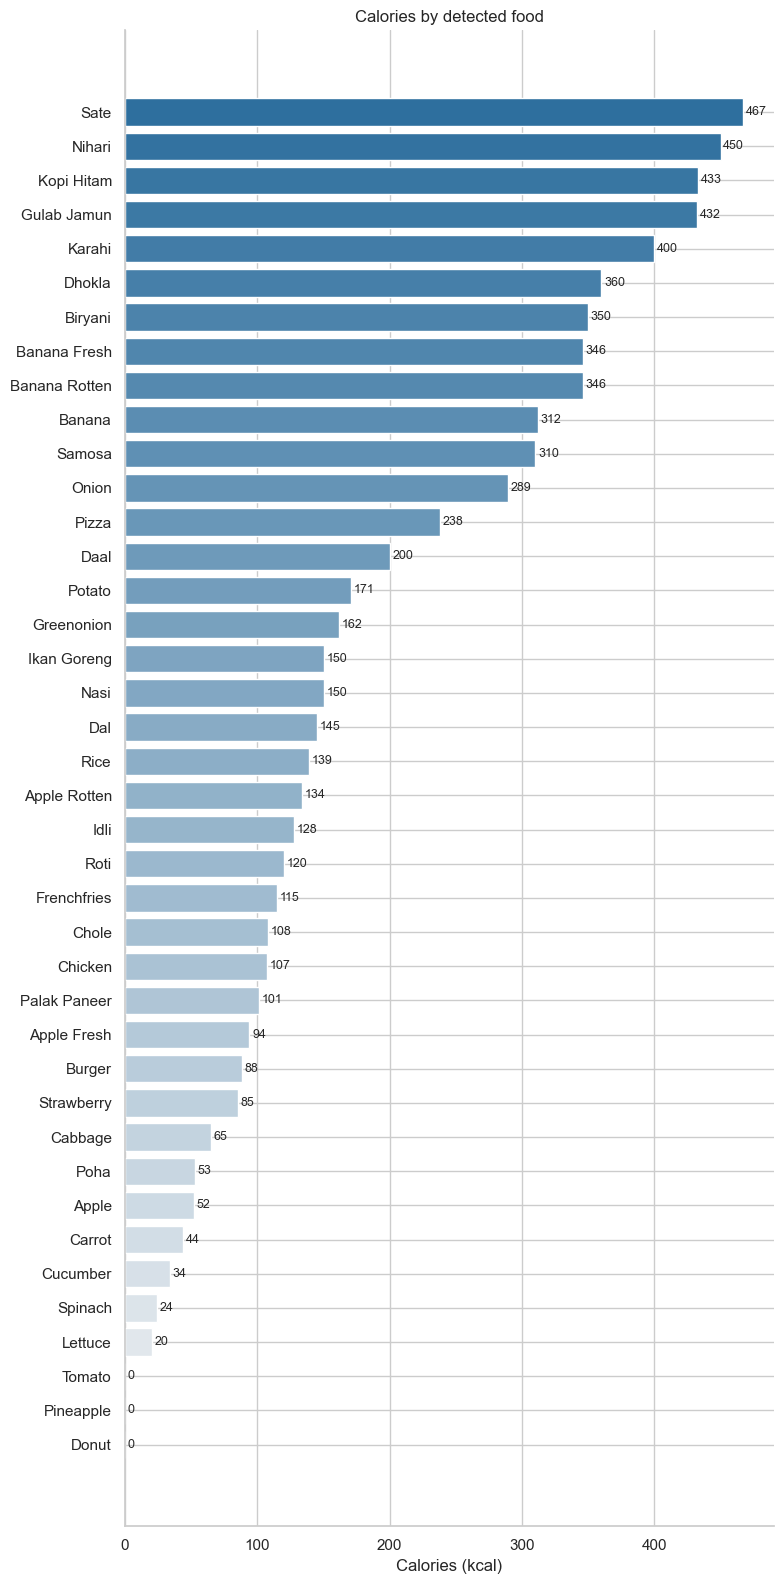

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.0)

# A single steady hue for magnitude comparisons (calories) — dark = higher.
plot_df = nutrition_df.dropna(subset=['calories']).sort_values('calories', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(plot_df))))
colors = sns.light_palette('#2E6F9E', n_colors=len(plot_df))
bars = ax.barh(plot_df['class_name'].str.title(), plot_df['calories'], color=colors)
for bar, val in zip(bars, plot_df['calories']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', fontsize=9)
ax.set_xlabel('Calories (kcal)')
ax.set_title('Calories by detected food')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'calories_by_food.png'), dpi=150)
plt.show()


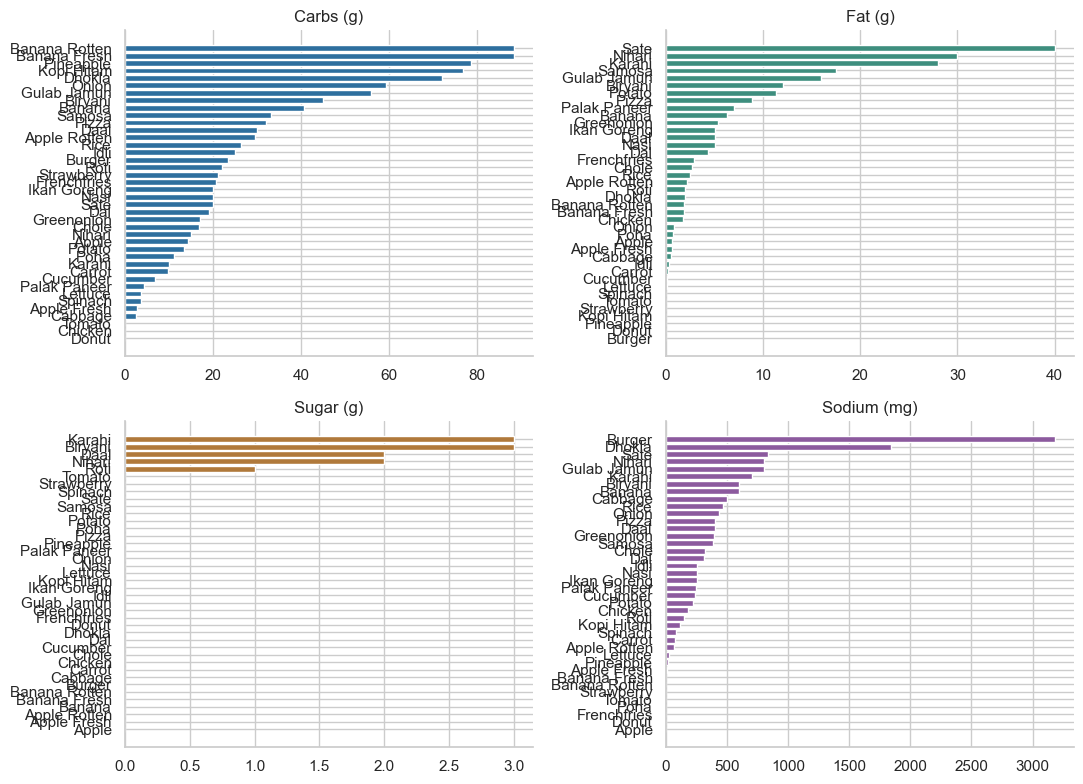

In [80]:

nutrients_to_plot = [
    ('carbs_g', 'Carbs (g)'),
    ('fat_g', 'Fat (g)'),
    ('sugar_g', 'Sugar (g)'),
    ('sodium_mg', 'Sodium (mg)'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
palette = ['#2E6F9E', '#3E8E7E', '#B0793B', '#8C5A9E']

for ax, (col, label), color in zip(axes.flat, nutrients_to_plot, palette):
    d = nutrition_df.dropna(subset=[col]).sort_values(col, ascending=True)
    ax.barh(d['class_name'].str.title(), d[col], color=color)
    ax.set_title(label)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'macros_small_multiples.png'), dpi=150)
plt.show()


In [83]:
import os
import pandas as pd
from ultralytics import YOLO


best_weights = '/content/runs/food_detector/weights/best.pt'
model = YOLO(best_weights)


nutrition_csv_path = os.path.join(NUTRITION_DIR, 'nutrition_table.csv')
nutrition_df = pd.read_csv(nutrition_csv_path)


TEST_IMAGE = os.path.join(BASE_DIR, 'biriyani.jpg')


def analyze_plate(image_path, user_conditions, model=model, nutrition_df=nutrition_df, conf=0.4):
    results = model.predict(source=image_path, conf=conf, save=False, verbose=False)
    detected = sorted({model.names[int(box.cls)] for r in results for box in r.boxes})

    if not detected:
        print("No food detected — try a clearer or closer photo.")
        return []                      # <- was bare `return`

    print(f"Detected: {', '.join(detected)}\n" + "="*50)

    for food in detected:
        print(f"\n- {check_food_suitability(food, user_conditions, nutrition_df)}")
        match = nutrition_df[nutrition_df['class_name'].str.lower() == food.lower()]
        if not match.empty:
            row = match.iloc[0]
            print(f"  Nutritional Values ({row['serving_description']}):")
            print(f"    • Calories: {row['calories']} kcal")
            print(f"    • Carbohydrates: {row['carbs_g']} g")
            print(f"    • Sugar: {row['sugar_g']} g")
            print(f"    • Fat: {row['fat_g']} g")
            print(f"    • Cholesterol: {row['cholesterol_mg']} mg")
            print(f"    • Sodium: {row['sodium_mg']} mg")
        else:
            print("  Detailed nutrition data not found in table.")

    return detected

analyze_plate(TEST_IMAGE, user_conditions=['diabetes', 'hypertension'])

Detected: biryani

- Biryani (350.0 kcal per 1 cup (~250g)): CAUTION — carbs g is 45.0 (above the 30 guideline for diabetes); sodium mg is 600.0 (above the 400 guideline for hypertension).
  Nutritional Values (1 cup (~250g)):
    • Calories: 350.0 kcal
    • Carbohydrates: 45.0 g
    • Sugar: 3 g
    • Fat: 12.0 g
    • Cholesterol: 45.0 mg
    • Sodium: 600.0 mg


['biryani']

In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
def bmi(w, h_cm):
    return w / (h_cm / 100) ** 2


def idx_age(age):
    return 0 if age < 40 else 1 if age < 50 else 2 if age < 60 else 3 if age < 70 else 4


def idx_bmi(b):
    return 0 if b < 23 else 1 if b < 25 else 2 if b < 30 else 3


def idx_activity(level):
    return {'sedentary': 2, 'light': 1, 'moderate': 0, 'active': 0}[level]


WEIGHTS = {
    'diabetes':     dict(age=0.75, bmi=1, act=0.5, sex=1, fam_diabetes=1, fam_heart=0, fam_htn=0, fam_stroke=0, sugar=2, sodium=0, fat=0, chol=0),
    'cvd':          dict(age=1,    bmi=1, act=1,   sex=1, fam_diabetes=0, fam_heart=2, fam_htn=1, fam_stroke=1, sugar=0, sodium=2, fat=1, chol=1),
    'heart_attack': dict(age=1,    bmi=1, act=1,   sex=1, fam_diabetes=1, fam_heart=3, fam_htn=1, fam_stroke=1, sugar=0, sodium=2, fat=1, chol=2),
}


FAM_MULT = {0: 0.0, 1: 1.0, 2: 1.6}
FAM_KEYS = [('diabetes', 'fam_diabetes'), ('heart_disease', 'fam_heart'),
            ('hypertension', 'fam_htn'), ('stroke', 'fam_stroke')]


def risk_score(condition, profile, diet):
    w = WEIGHTS[condition]
    fam = profile.get('family_history', {})
    b = bmi(profile['weight_kg'], profile['height_cm'])

    fam_total = sum(w[wkey] * FAM_MULT.get(int(fam.get(fkey, 0)), 1.5)
                    for fkey, wkey in FAM_KEYS)

    pts = (
        idx_age(profile['age']) * w['age']
        + idx_bmi(b) * w['bmi']
        + idx_activity(profile['activity']) * w['act']
        + (w['sex'] if profile['sex'] == 'male' else 0)
        + fam_total
        + (w['sugar'] if diet.get('sugar_g', 0) > 50 else 0)
        + (w['sodium'] if diet.get('sodium_mg', 0) > 2000 else 0)
        + (w['fat'] if diet.get('fat_g', 0) > 70 else 0)
        + (w['chol'] if diet.get('cholesterol_mg', 0) > 300 else 0)
    )
    max_pts = (4 * w['age'] + 3 * w['bmi'] + 2 * w['act'] + w['sex']
               + 1.5 * sum(w[wkey] for _, wkey in FAM_KEYS)
               + w['sugar'] + w['sodium'] + w['fat'] + w['chol'])
    pct = 100 * pts / max_pts
    level = 'Low' if pct < 30 else 'Moderate' if pct < 55 else 'High' if pct < 80 else 'Very High'
    return round(pts, 1), round(max_pts, 1), level


def assess(profile, diet):
    return {c: risk_score(c, profile, diet) for c in WEIGHTS}


def diet_from_foods(foods, nutrition_df):
    rows = nutrition_df[nutrition_df['class_name'].str.lower().isin([f.lower() for f in foods])]
    cols = ['calories', 'carbs_g', 'sugar_g', 'fat_g', 'cholesterol_mg', 'sodium_mg']
    return {c: float(rows[c].sum()) for c in cols}


def get_profile():
    age = int(input('Age: '))
    sex = input('Sex (male/female): ').strip().lower()
    height_cm = float(input('Height (cm): '))
    weight_kg = float(input('Weight (kg): '))
    activity = input('Activity (sedentary/light/moderate/active): ').strip().lower()
    fam = {}
    for fkey, _ in FAM_KEYS:
        while True:
            ans = input(f'How many parents have/had {fkey.replace("_", " ")}? (0/1/2): ').strip()
            if ans in ('0', '1', '2'):
                fam[fkey] = int(ans)
                break
            print('  Please enter 0, 1 or 2.')
    return dict(age=age, sex=sex, height_cm=height_cm, weight_kg=weight_kg,
                activity=activity, family_history=fam)


if __name__ == '__main__':
    profile = get_profile()
    detected = analyze_plate(TEST_IMAGE, user_conditions=[])
    diet = diet_from_foods(detected, nutrition_df) if detected else dict(sugar_g=0, sodium_mg=0, fat_g=0, cholesterol_mg=0)

    print(f"\nDetected food used in this score: {', '.join(detected) if detected else 'none'}")
    for cond, (pts, mx, level) in assess(profile, diet).items():
        print(f"{cond}: {level} ({pts}/{mx})")
    print("Screening only -- not a diagnosis. See a doctor for real evaluation.")

Age: 47
Sex (male/female): male
Height (cm): 190
Weight (kg): 91
Activity (sedentary/light/moderate/active): light
How many parents have/had diabetes? (0/1/2): 2
How many parents have/had heart disease? (0/1/2): 2
How many parents have/had hypertension? (0/1/2): 1
How many parents have/had stroke? (0/1/2): 1
Detected: biryani

- Biryani (350.0 kcal per 1 cup (~250g)): looks fine in a normal portion.
  Nutritional Values (1 cup (~250g)):
    • Calories: 350.0 kcal
    • Carbohydrates: 45.0 g
    • Sugar: 3 g
    • Fat: 12.0 g
    • Cholesterol: 45.0 mg
    • Sodium: 600.0 mg

Detected food used in this score: biryani
diabetes: Moderate (5.8/11.5)
cvd: Moderate (10.2/20.0)
heart_attack: High (13.4/24.0)
Screening only -- not a diagnosis. See a doctor for real evaluation.


## Sources

- [Indian Food Detection — Roboflow Universe](https://universe.roboflow.com/project-z0tql/indian-food-detection-kzw9g)
- [Indian Food YOLOv5 — Roboflow Universe](https://universe.roboflow.com/smart-india-hackathon/indian-food-yolov5)
- [Pakistani-Food-Recognizer — GitHub](https://github.com/ahsantahseen/Pakistani-Food-Recognizer)
- [Fast Food Finder — Roboflow Universe](https://universe.roboflow.com/algebra/fast-food-finder)
- [Fast Food Dataset — Roboflow Universe](https://universe.roboflow.com/fast-food-dataset/fast-food-dataset-zpies)
- [Fruits and Vegetables — Roboflow Universe](https://universe.roboflow.com/datasets-wqqwv/fruits-and-vegetables-un1ow)
- [Fruits and Vegetable Detection — Roboflow Universe](https://universe.roboflow.com/e3/fruits-and-vegetable-detection-y0n90)
- [Food-101 Dataset — Roboflow Universe](https://universe.roboflow.com/gec-bilaspur/food-101-dataset)
- [USDA FoodData Central API](https://fdc.nal.usda.gov/api-key-signup)
